# US Census Demographic Data
### Predykcja dochodu na osobę w zależności od danych demograficznych i ekonomicznych w Stanach Zjednoczonych

In [5]:
import numpy as np
import pandas as pd

Wczytanie zbioru i określenie liczby hrabstw

In [6]:
df = pd.read_csv("data/acs2017_county_data.csv")

display(df.head())

num_counties = df.shape[0]
print("Liczba hrabstw:",num_counties)

num_attr = df.shape[1]
print("Liczba atrybutów:", num_attr)

print("Nazwy atrybutów:")
print(df.columns.values)

df.drop_duplicates()

num_counties_aft_drop = df.shape[0]
if num_counties != num_counties_aft_drop:
    print("Występują powtórzenia w zbiorze i jest ich:", num_counties - num_counties_aft_drop)

,CountyId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001,Alabama,Autauga County,55036,26899,28137,2.7,75.4,18.9,0.3,...,0.6,1.3,2.5,25.8,24112,74.1,20.2,5.6,0.1,5.2
1,1003,Alabama,Baldwin County,203360,99527,103833,4.4,83.1,9.5,0.8,...,0.8,1.1,5.6,27.0,89527,80.7,12.9,6.3,0.1,5.5
2,1005,Alabama,Barbour County,26201,13976,12225,4.2,45.7,47.8,0.2,...,2.2,1.7,1.3,23.4,8878,74.1,19.1,6.5,0.3,12.4
3,1007,Alabama,Bibb County,22580,12251,10329,2.4,74.6,22.0,0.4,...,0.3,1.7,1.5,30.0,8171,76.0,17.4,6.3,0.3,8.2
4,1009,Alabama,Blount County,57667,28490,29177,9.0,87.4,1.5,0.3,...,0.4,0.4,2.1,35.0,21380,83.9,11.9,4.0,0.1,4.9


Liczba hrabstw: 3220
Liczba atrybutów: 37
Nazwy atrybutów:
['CountyId' 'State' 'County' 'TotalPop' 'Men' 'Women' 'Hispanic' 'White'
 'Black' 'Native' 'Asian' 'Pacific' 'VotingAgeCitizen' 'Income'
 'IncomeErr' 'IncomePerCap' 'IncomePerCapErr' 'Poverty' 'ChildPoverty'
 'Professional' 'Service' 'Office' 'Construction' 'Production' 'Drive'
 'Carpool' 'Transit' 'Walk' 'OtherTransp' 'WorkAtHome' 'MeanCommute'
 'Employed' 'PrivateWork' 'PublicWork' 'SelfEmployed' 'FamilyWork'
 'Unemployment']


Usunięcie atrybutu ID hrabstwa

In [7]:
df = df.drop("CountyId", axis = 1)

Analiza braków danych

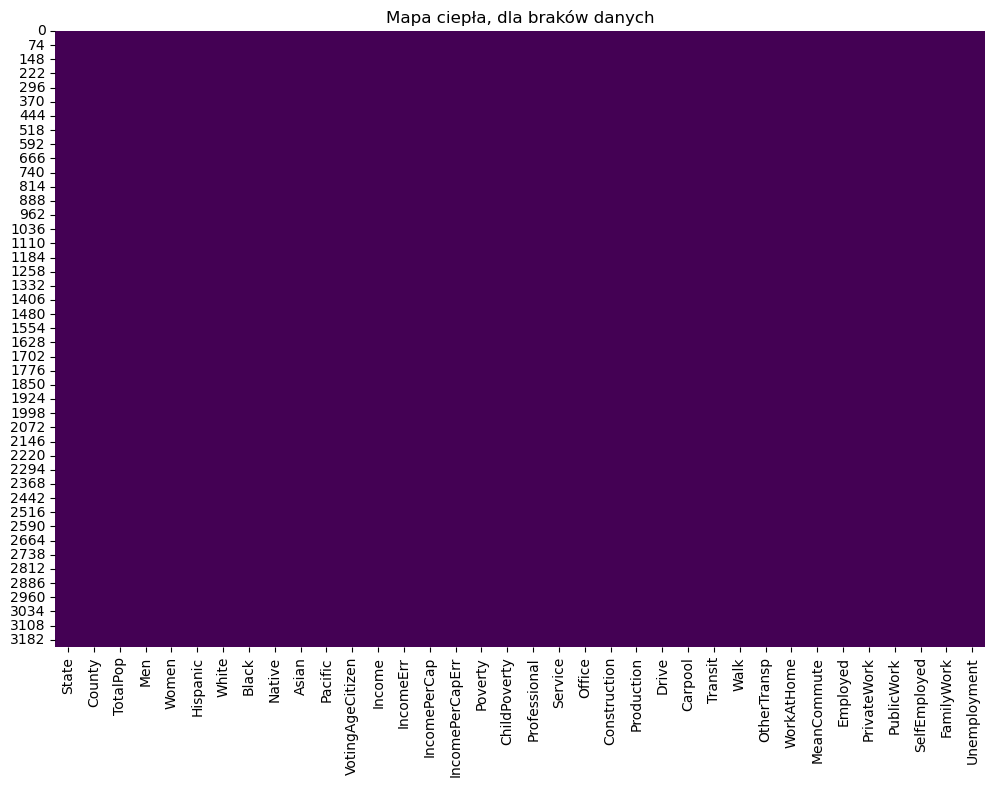

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [8]:
from missing_values import analyze

analyze(df)

In [5]:
print("Hrabstwo, dla którego występuje brak:", df.loc[548, "County"])
print()

Hrabstwo, dla którego występuje brak: Kalawao County



Hrabstwo to ma ok. 80 mieszkańców i znajduje się w stanie Hawaii, więc myślę, że można je pominąć w analizie

Kolumna, dla której występował brak

In [6]:
df["ChildPoverty"]

0       20.1
1       16.1
2       44.9
3       26.6
4       25.4
        ... 
3215    49.4
3216    68.2
3217    67.9
3218    62.1
3219    58.2
Name: ChildPoverty, Length: 3220, dtype: float64

In [7]:
df = df.dropna()
print("Ilość obiektów po usunięcie braków:", df.shape[0])

Ilość obiektów po usunięcie braków: 3219


In [8]:
# indeksy atrybutów, które chcemy wczytać
col_idx = list(range(213, 225))
col_idx.insert(0, 2)
df_m = pd.read_csv("data/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv", usecols = col_idx)

df_m.head()

,RegionName,2017-01-31,2017-02-28,2017-03-31,2017-04-30,2017-05-31,2017-06-30,2017-07-31,2017-08-31,2017-09-30,2017-10-31,2017-11-30,2017-12-31
0,Los Angeles County,496432.165871,507859.677641,520913.658719,530631.397967,537244.275959,542477.432796,542385.620441,540013.644416,536369.348970,536864.968049,538689.381948,541662.049466
1,Cook County,213212.551902,214911.562420,216700.376163,217918.756026,218702.731358,218548.139244,218452.791111,218348.257780,219114.410602,220283.185939,221663.939129,223089.429643
2,Harris County,178867.362531,179293.936080,179865.512649,180606.507008,181295.097794,181900.420107,182275.200113,182736.328973,183150.923275,183801.630746,184547.835710,185331.960500
3,Maricopa County,246051.872009,247371.898175,248821.126990,250356.606120,251795.821571,253212.799829,254578.486102,256004.502478,257477.687867,259015.835934,260282.302938,261556.469755
4,San Diego County,527134.172852,531398.707245,534337.134033,537429.740566,540009.645298,543344.843806,545744.662180,549008.592430,552204.949203,556710.483291,560643.580571,565084.374180



Braki w danych liczone wg. kolumn
2017-01-31    101
2017-02-28     95
2017-03-31     94
2017-04-30     94
2017-05-31     94
2017-06-30     94
2017-07-31     94
2017-08-31     94
2017-09-30     94
2017-10-31     94
2017-11-30     94
2017-12-31     94
dtype: int64

Braki w danych liczone wg. obiektów
1062    12
1734    12
1857    12
2062    12
2161     1
        ..
3068    12
3069    12
3070    12
3071    12
3072    12
Length: 101, dtype: int64


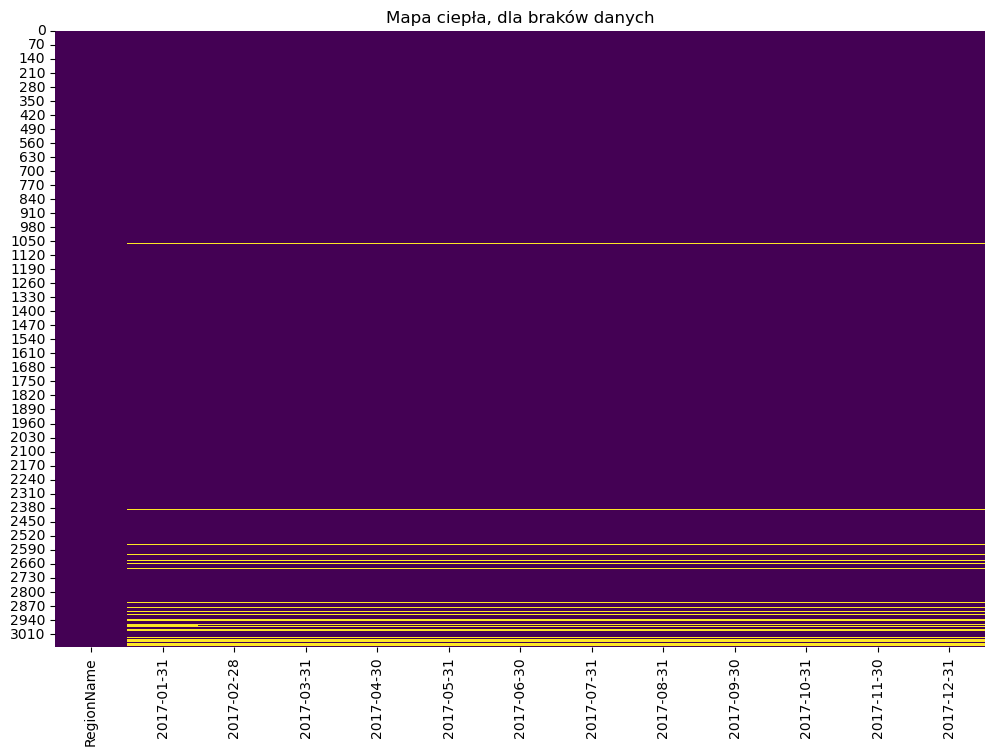

In [9]:
from missing_values import analyze

analyze(df_m)